# Fractal Growth from Random Motion: Diffusion-Limited Aggregation
---

## 1. Meeting our Friend again
---

We have heard that a pollen grain moves in the wind until it falls on the stigma it sticks to initiate fertilization of the flower. Or an asteroid hitting the planet if it flies too close to the planet. In both these cases, we can think of one thing, that the planet, the stigma is the destination and the walker, the pollen and the asteroid  these are the particles moving around. 

Or we can think of our drunk friend from all random walk examples, he now is not in the bar yet but drunk enough to move randomly but tonight he is trying to find the bar. And we would be seeing if he suceeds or not. But tonight it is dangerous, because a killer is moving at around 30 units from the bar, and if he goes that far, he will be no more, a lot is at stake here. Imagine the city gates are at around 10 units from the bar and he got the strength to walk another 1000 steps, will he reach the bar? or be killed by our antagonist? or be in the same place stuck till it reaches 1000 steps. We try to simulate that first.

And this, strangely enough, is how crystals grow. How lightning finds its path. How dust becomes planets. A single particle, wandering without purpose, until the moment of contact changes everything. The drunk man's fate tonight is also the universe's favorite way of building complexity: one random step at a time.

---

Now let us plot our drunk friend, and check whether he can reach the bar or just be left out in the cold night or would he become a bad fate and reach far into the danger zone.



Stuck


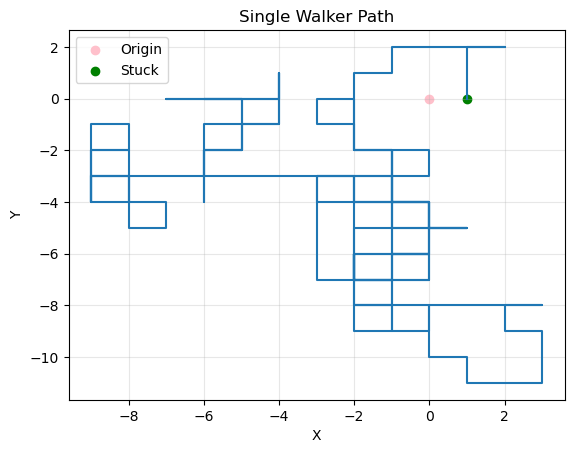

In [41]:
import random
import matplotlib.pyplot as plt
import math

origin = [0,0]

kill=stuck=False

R_birth= 10
R_kill=30

angle=random.uniform(0,2*math.pi)
x=int(R_birth * math.cos(angle))
y=int(R_birth * math.sin(angle))

loc_x=[x]
loc_y=[y]

steps=1000
for _ in range(steps):
    dx,dy= random.choice([(0,1),(0,-1),(1,0),(-1,0)])
    x+=dx
    y+=dy
    if math.sqrt((x**2)+(y**2))>R_kill:
        kill=True
        print("killed")
        break
        
    loc_x.append(x)
    loc_y.append(y)

    dist = math.sqrt((x-origin[0])**2+(y-origin[1])**2)

    if dist<=1 and dist>0:
        stuck=True
        print("Stuck")
        break

plt.plot(loc_x,loc_y)
plt.scatter(origin[0],origin[1], color= 'pink', label= 'Origin')
if stuck:
    plt.scatter(x,y, color = 'green', label='Stuck')
if kill:
    plt.scatter(x,y, color ='red' , label= "Killed")
if not stuck and not kill:
    print("Steps Over")
    plt.scatter(x,y, color = 'yellow', label= "Stopped")

plt.title('Single Walker Path')
plt.xlabel('X')
plt.ylabel('Y')

plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

**RESULT**

As we can see in the previous run, our drunk friend finally got to reach the bar. He walked randomly through the streets one step at a time which lead him to the door of the bar. But alas, the door of the bar was shut,and he stood there holding the door handle trying to open it.

Till now we have simulated a particle/object from random walk to reach a specific position and also having a final boundary beyond which the particle doesnt exist anymore.

## 2. Emergence of the Fractal - A Thousand Walkers
---

As we have seen in all our previous notebooks, one run is just a chance, multiple runs teach us how probable the action was. Whether here our dear friend was lucky to reach the bar, or anyone could do that? To answer that specific question we now simulate it 1000 times, but there is a catch if a new person comes in, as the bar is closed he will be standing behind our first friend forming a random queue of drunk people who walked randomly to the bar. 

Scientifically speaking these particles will come together to be deposited over the previous, if we imagine another pollen grain landing beside the first, or during electroplating, if another atom of the depositing element comes in it generally rests in either in another open area available or it gets deposited over the last one. Such a method that follows a random walk (like **diffusion**) and its growth is **limited** on how fast another particle arrives there (like when the next particle comes to the same spot we can only see the growth then) and the particles clumping together making an **aggregate**, this is called *Diffusion Limited Aggregation* or **DLA**. This scientific phenomenon links from electroplating to snowflakes growth from Lightning to creation of river networks. 

---
For now let us simulate 1000 drunk people of the town who got stuck to the door and who got removed by our killer waiting at 30 units away from the bar

Stuck: 952
Killed: 44


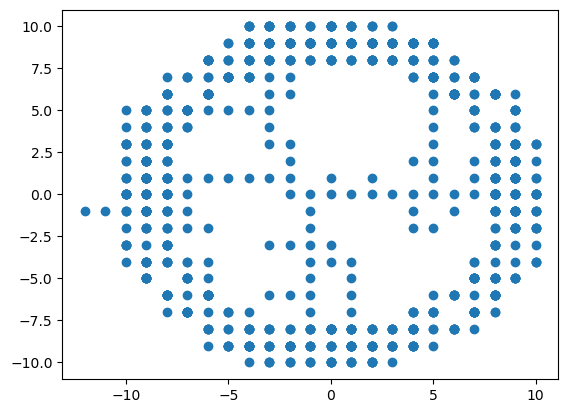

In [52]:
import random
import matplotlib.pyplot as plt
import math

origin= [0,0]
R_birth=10
R_kill=30

kill=0
stickx=[0]
sticky=[0]

def check_stuck(x,y,stickx,sticky):
    for k in range(len(stickx)):
        sx=stickx[k]
        sy=sticky[k]
        if math.sqrt((x-sx)**2+(y-sy)**2)<=1:
            return True
    return False

for i in range (1000):
    angle= random.uniform(0, 2*math.pi)
    x=int(R_birth*math.cos(angle))
    y=int(R_birth*math.sin(angle))
    
    locx=[x]
    locy=[y]
    for j in range(1000):
        dx,dy=random.choice([(1,0),(-1,0),(0,1),(0,-1)])
        x+=dx
        y+=dy
        dist=math.sqrt(x**2+y**2)
        
        if dist>R_kill:
            kill+=1
            break
        if check_stuck(x,y,stickx,sticky):
            stickx.append(x)
            sticky.append(y)
            break

print(f"Stuck: {len(stickx)-1}")
print(f"Killed: {kill}")
plt.scatter(stickx,sticky)
plt.show()

**RESULT**

We can see from the statistics that most of the drunk people 952 people get stuck and 44 people go far out of bounds and only 40 people get stuck in a loop that they couldnt cover the distance under 1000 steps. 

But there is a problem with our first run, our birth radius is small. As more people arrive and the cluster grows outward, new walkers are being spawned closer and closer to the already-stuck crowd. Some are born already touching the cluster. The fractal is trapped, it cannot grow beyond the invisible cage of its own birth condition.

Still, even within this cage, the cluster formed is not random. It has
structure. It has branches. It is a **fractal**. To understand a fractal we need a larger system to begin with.


## 3. Breaking the Cage
---

The fixed birth radius trapped our fractal, walkers who spawned too close are sometimes inside the cluster itself. To let the fractal grow freely, the birth radius must grow with it.

After each walker sticks we check how far the cluster has reached. We set the new birth radius to that distance plus a buffer. This birth radius will be a dynamic one. 

To make it a dynamic birth radius, we check the highest value of the stuck particles and then add 5 to increase the extent and create a new birth area everytime.


Stuck: 343
Killed: 655


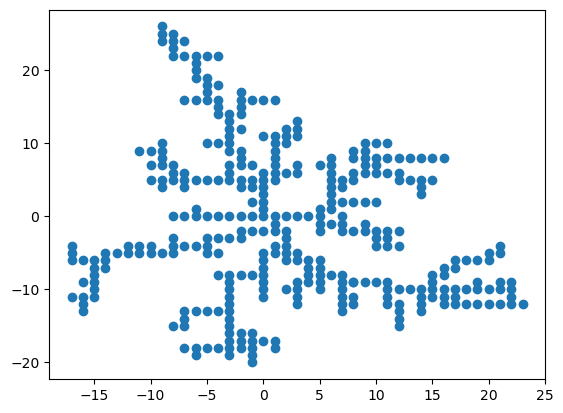

In [55]:
import random
import matplotlib.pyplot as plt
import math

origin= [0,0]
R_birth=10
R_kill=30

kill=0
stickx=[0]
sticky=[0]

def check_stuck(x,y,stickx,sticky):
    for k in range(len(stickx)):
        sx=stickx[k]
        sy=sticky[k]
        if math.sqrt((x-sx)**2+(y-sy)**2)<=1:
            return True
    return False

for i in range (1000):
    angle= random.uniform(0, 2*math.pi)
    x=int(R_birth*math.cos(angle))
    y=int(R_birth*math.sin(angle))
    
    locx=[x]
    locy=[y]
    for j in range(1000):
        dx,dy=random.choice([(1,0),(-1,0),(0,1),(0,-1)])
        x+=dx
        y+=dy
        dist=math.sqrt(x**2+y**2)
        
        if dist>R_kill:
            kill+=1
            break
        if check_stuck(x,y,stickx,sticky):
            stickx.append(x)
            sticky.append(y)
            max_extent = max(max(abs(x) for x in stickx), max(abs(y) for y in sticky))
            R_birth = max_extent + 5
            break

print(f"Stuck: {len(stickx)-1}")
print(f"Killed: {kill}")
plt.scatter(stickx,sticky)
plt.show()

**RESULT**

But looking at the birth and death rates here, we can see, that increasing only the birth radius to dynamic caused the death rate to spike up, and this happens as the birth radius becomes closer to the killer's radius one wrong step can lead to people getting decimated by it.

To remove that we change the death radius to dynamic, just imagine a police is patrolling in a car, or chasing the killer away from the people.

Lets change the death radius and fix the issue.

Stuck: 491
Killed: 2


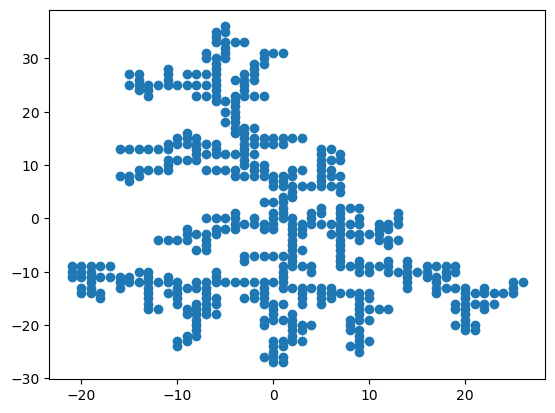

In [56]:
import random
import matplotlib.pyplot as plt
import math

origin= [0,0]
R_birth=10
R_kill=30

kill=0
stickx=[0]
sticky=[0]

def check_stuck(x,y,stickx,sticky):
    for k in range(len(stickx)):
        sx=stickx[k]
        sy=sticky[k]
        if math.sqrt((x-sx)**2+(y-sy)**2)<=1:
            return True
    return False

for i in range (1000):
    angle= random.uniform(0, 2*math.pi)
    x=int(R_birth*math.cos(angle))
    y=int(R_birth*math.sin(angle))
    
    locx=[x]
    locy=[y]
    for j in range(1000):
        dx,dy=random.choice([(1,0),(-1,0),(0,1),(0,-1)])
        x+=dx
        y+=dy
        dist=math.sqrt(x**2+y**2)
        
        if dist>R_kill:
            kill+=1
            break
        if check_stuck(x,y,stickx,sticky):
            stickx.append(x)
            sticky.append(y)
            max_extent = max(max(abs(x) for x in stickx), max(abs(y) for y in sticky))
            R_birth = max_extent + 5
            R_kill+=5
            break

print(f"Stuck: {len(stickx)-1}")
print(f"Killed: {kill}")
plt.scatter(stickx,sticky)
plt.show()

**RESULT**

As we can see here that most of the people 506 people out of 1000 did not complete the run at all, the gap between the R_kill and R_birth grew so much that most of people lost their step count before getting stuck or going out of bounds. For 492 people who got stuck to the cluster the value of R_kill went from 30 to 30+492x5 = 2490 thus the out of bounds zone went so far that the runners can wander almost forever. And thus it creates more bloated fractals we can say here for such a high value.  

## 4. Too Much Safety Ruins the Fractal
---

To counter the problem, that the R_kill going so far off that we can introduce a factor, i.e, the ratio of R_kill to R_birth. That way we can check for which ratio the fractal comes out the most beautiful one. 

In theory we can say that : A fractal needs selective growth. Tips must capture walkers before gaps can fill. If every walker survives, every gap gets filled, and
the fractal becomes a blob. The killer is not the enemy. The killer is the sculptor.

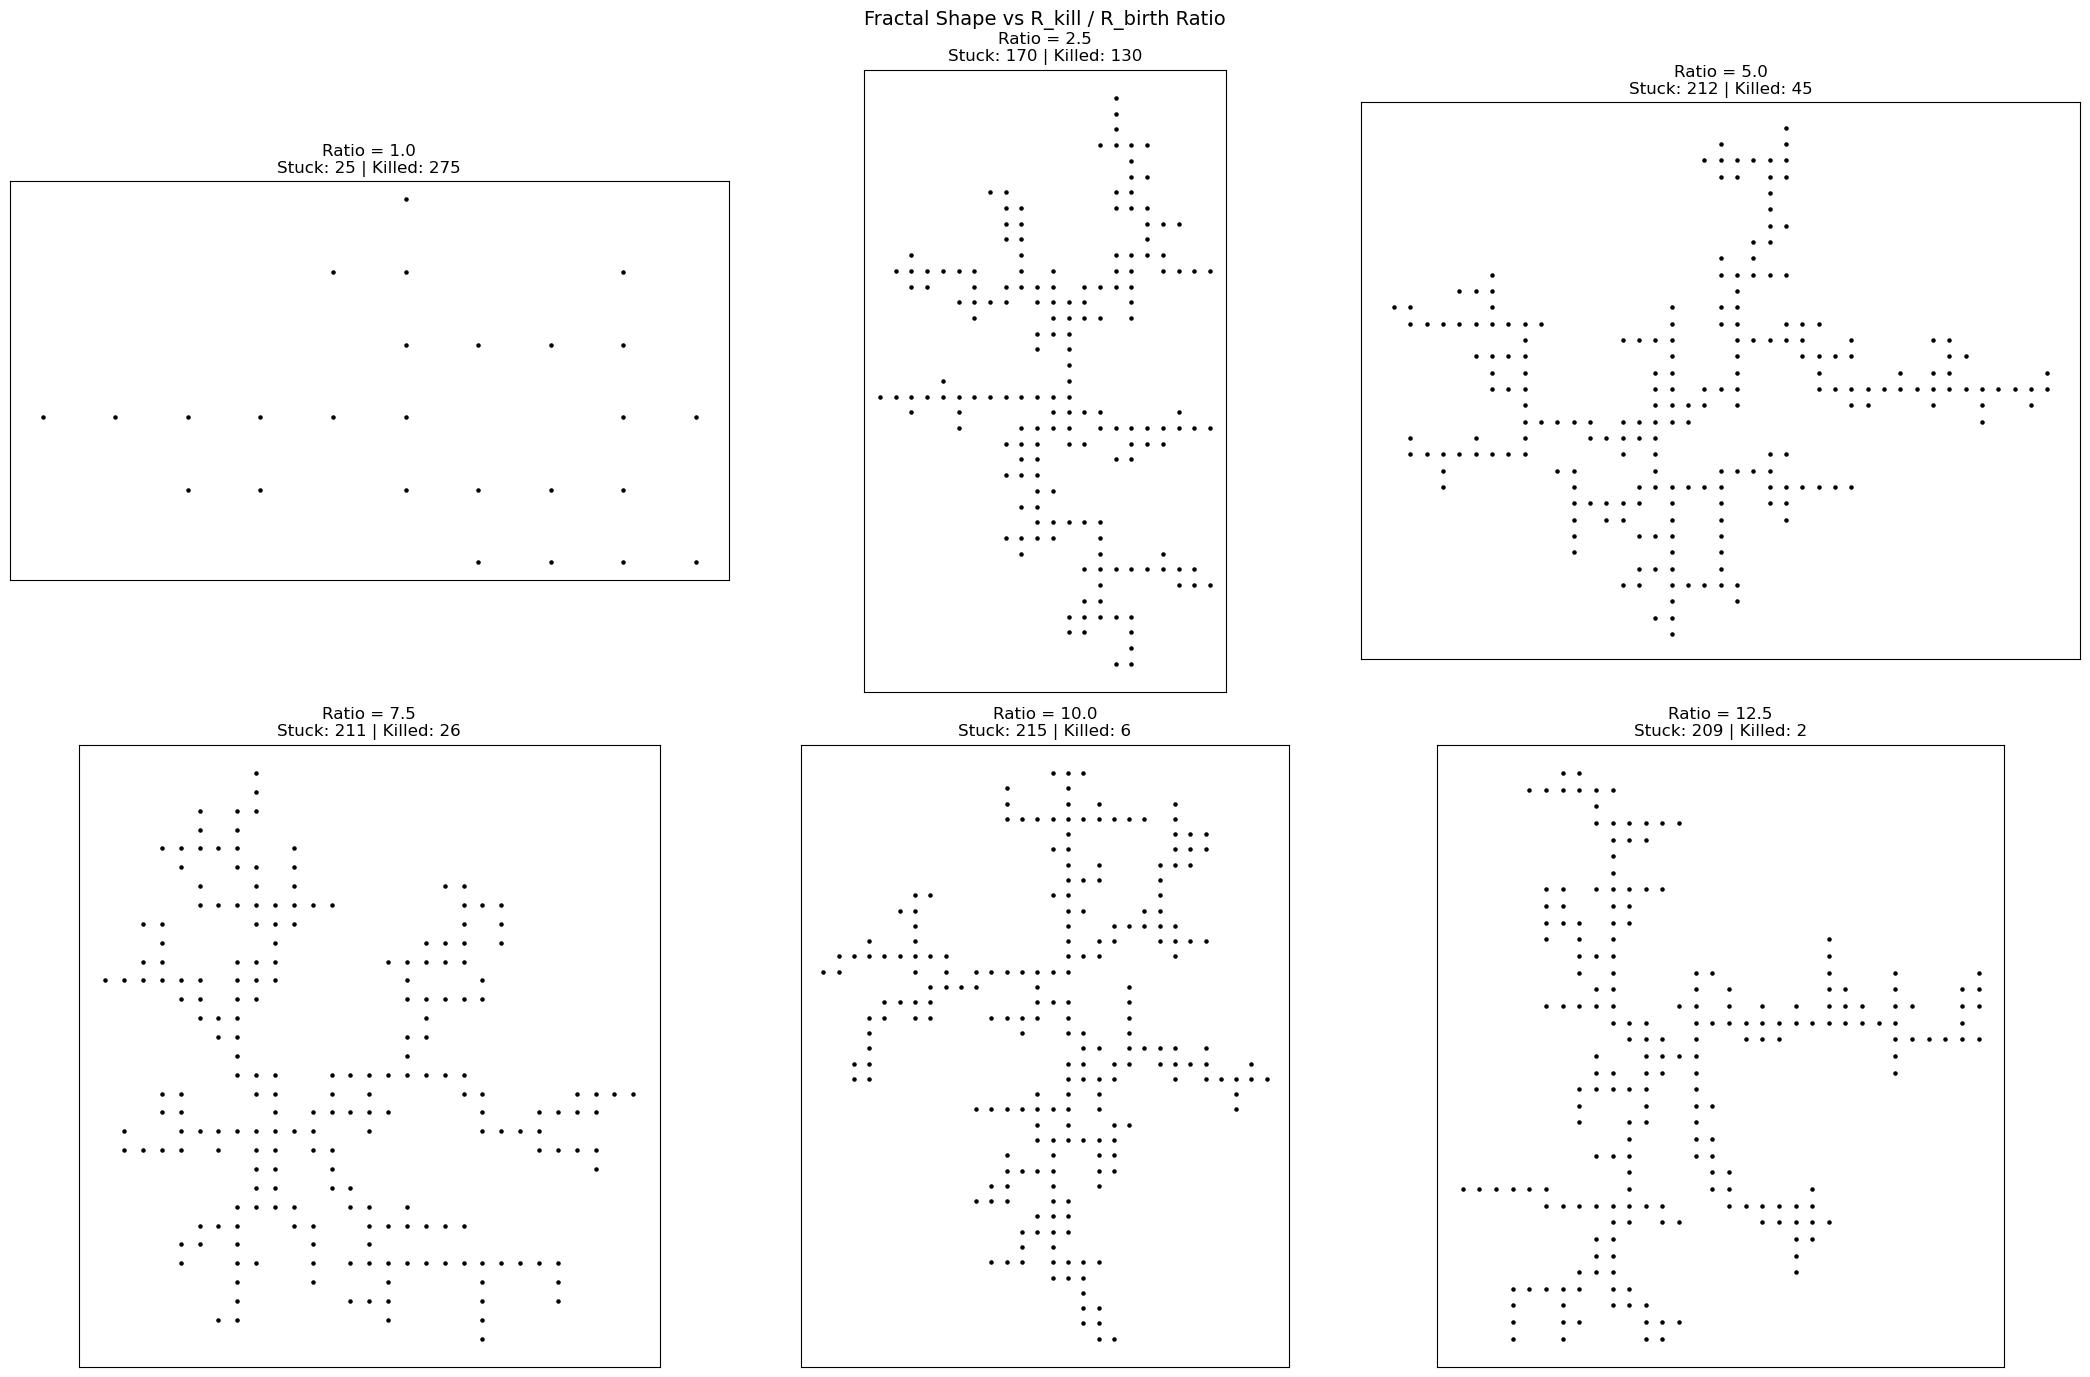

In [69]:
import random
import matplotlib.pyplot as plt
import math

def run_dla(ratio, attempts=300):
    stickx = [0]
    sticky = [0]
    killed = 0
    
    for i in range(attempts):
        max_extent = max(max(abs(x) for x in stickx), max(abs(y) for y in sticky))
        R_birth = max(max_extent + 5, 10)
        R_kill = R_birth * ratio
        
        angle = random.uniform(0, 2 * math.pi)
        x = int(R_birth * math.cos(angle))
        y = int(R_birth * math.sin(angle))
        
        for _ in range(5000):
            dx, dy = random.choice([(1,0), (-1,0), (0,1), (0,-1)])
            x += dx
            y += dy
            
            if math.sqrt(x**2 + y**2) > R_kill:
                killed += 1
                break
            
            stuck = False
            for k in range(len(stickx)):
                if math.sqrt((x - stickx[k])**2 + (y - sticky[k])**2) <= 1:
                    stickx.append(x)
                    sticky.append(y)
                    stuck = True
                    break
            if stuck:
                break
    
    return stickx, sticky, killed

ratios = [1.0, 2.5, 5.0, 7.5, 10.0, 12.5 ]
fig, axes = plt.subplots(2, 3, figsize=(21, 14))

row=0
col=0
for ratio in ratios:
    sx, sy, killed = run_dla(ratio)
    axes[row, col].scatter(sx, sy, s=5, color='black')
    axes[row, col].set_title(f'Ratio = {ratio}\nStuck: {len(sx)-1} | Killed: {killed}')
    axes[row, col].set_xticks([])
    axes[row, col].set_yticks([])
    axes[row, col].set_aspect('equal')
    col+=1
    if col==3:
        row+=1
        col=0

plt.suptitle('Fractal Shape vs R_kill / R_birth Ratio', fontsize=14)
plt.tight_layout()
plt.show()

This comparison perfectly illustrates the central trade-off in Diffusion-Limited Aggregation (DLA). By increasing the number of trials and varying the ratios, you have effectively visualized the transition from a **survival-dominated blob** to an **efficiency-limited void**.

1. The "Death Zone" (Ratio 1.0): With the killer right at the city gates, almost everyone is decimated (275 killed out of 300). Complexity can't even begin to form because the environment is too hostile to allow for random movement.
  
2. The "Sweet" Spot (Ratios 5.0 - 7.5): At these ratios, the "killer" is active enough to remove walkers that wander too far, but not so far that growth stops.As a result we get long, spindly "fingers" that resemble real-world phenomena.

3. The Efficiency Trap (Ratios 10.0 - 12.5): These look "cleaner" but "separated" because you are seeing the limit of the simulation. This is your "aimless wandering" point. We can notice how the number of "Killed" walkers drops to almost zero (only 2 killed at ratio 12.5). This does mean that it's safer; but it means the world is so huge that the walkers never even find the killer and they are likely exhausting their 1000 steps just wandering in empty space. They aren't contributing to complexity; they are just getting lost in the "cold night".

## 5. When Safety Becomes Emptiness
---

We try to figure out that if there exists a point where the kill rate vs radius ratio is perfect to plot out the best fractals. Let us check all values of kill Rate vs Radius Ratio for 20 ratios, from 1.0 to 20.0 and each point has 500 walker attempts and each walker can do upto 5000 steps. 


Ratio 1.0: Killed 442/500
Ratio 2.0: Killed 225/500
Ratio 3.0: Killed 175/500
Ratio 4.0: Killed 113/500
Ratio 5.0: Killed 70/500
Ratio 6.0: Killed 49/500
Ratio 7.0: Killed 31/500
Ratio 8.0: Killed 18/500
Ratio 9.0: Killed 16/500
Ratio 10.0: Killed 9/500
Ratio 11.0: Killed 7/500
Ratio 12.0: Killed 3/500
Ratio 13.0: Killed 2/500
Ratio 14.0: Killed 2/500
Ratio 15.0: Killed 1/500
Ratio 16.0: Killed 1/500
Ratio 17.0: Killed 0/500
Ratio 18.0: Killed 0/500
Ratio 19.0: Killed 0/500
Ratio 20.0: Killed 0/500


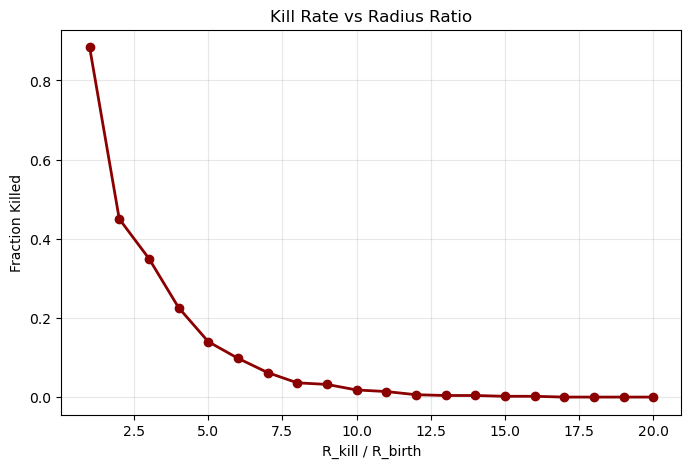

In [71]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math

ratios = np.linspace(1,20,20)
kill_fraction = []

for ratio in ratios:
    stickx = [0]
    sticky = [0]
    killed = 0
    stuck_count = 0
    attempts = 500
    
    for i in range(attempts):
        max_extent = max(max(abs(x) for x in stickx), max(abs(y) for y in sticky))
        R_birth = max(max_extent + 5, 10)
        R_kill = R_birth * ratio
        
        angle = random.uniform(0, 2 * math.pi)
        x = int(R_birth * math.cos(angle))
        y = int(R_birth * math.sin(angle))
        
        for _ in range(5000):
            dx, dy = random.choice([(1,0), (-1,0), (0,1), (0,-1)])
            x += dx
            y += dy
            dist = math.sqrt(x**2 + y**2)
            
            if dist > R_kill:
                killed += 1
                break
            
            # Check sticking
            stuck = False
            for k in range(len(stickx)):
                if math.sqrt((x - stickx[k])**2 + (y - sticky[k])**2) <= 1:
                    stickx.append(x)
                    sticky.append(y)
                    stuck_count += 1
                    stuck = True
                    break
            if stuck:
                break
    
    kill_fraction.append(killed / attempts)
    print(f"Ratio {ratio:.1f}: Killed {killed}/{attempts}")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(ratios, kill_fraction, marker='o', color='darkred', linewidth=2)
plt.xlabel('R_kill / R_birth')
plt.ylabel('Fraction Killed')
plt.title('Kill Rate vs Radius Ratio')
plt.grid(True, alpha=0.3)
plt.show()

**RESULT**

The curve drops sharply at first, then flattens into a long, slow approach to zero.

- At ratio 1.0, the killer is at the city gates. Nearly 90% of walkers die. The fractal starves before it can begin.

- By ratio 5.0, the kill rate has dropped to 14%. Walkers survive long enough to find the cluster and contribute to its branching arms. This is where the most visually striking fractals emerge long fingers, open gaps, true DLA.

- Beyond ratio 10.0, something unexpected happens. The kill rate approaches zero but the fractal does not improve. It plateaus. The walkers are not dying, but they are not contributing either. They exhaust their 1000 steps wandering in the vast empty space between birth and cluster. The killer is gone, but the cold night remains the point they cant walk anymore.

The curve reveals a truth we did not anticipate: the sweet spot is not a single point. It is a region from roughly 3.0 to 8.0 where enough walkers survive to build complexity, and enough die to keep the simulation efficient. Beyond that, safety becomes emptiness. 



## 6. Growth Rate of the Fractal
---

We've watched the cluster form. Now we check its scale. If we double the number of walker attempts, do we get double the stuck particles or does growth slow down as the cluster gets larger

This is not just curiosity. In electroplating, it determines how fast
a coating forms. In coral growth, it sets the pace of reef expansion.
Growth rate connects the microscopic rule — "stick on contact" — to
the macroscopic observable: how big, how fast.

We run DLA for increasing numbers of attempts and measure the final cluster size. 

**REMARK:**

Using the old code it was achievable to reach our goal of 5000 steps and 50000 walkers but that would take a very long time (it has taken like 34 mins to do 2000 steps of 50000 walkers) so we optimize the code. using sets we can instantly check instead of using lists, as sets check for the hash number, or like an index number which directs it to a specific number while lists itself run loops from 1 to n. For set it is O(1) and for lists it is O(n). Here we also check the neighborhood using direct method if there is any other particle located in the neighborhood. We also return sx and sy so that in future if we ever need to print a fractal we can just save `sx `and `sy` and print it out. Also I learnt that `math.sqrt()` calculates things in a Taylor Series format, it is time consuming so why not just square it and relate to the radius squared. The result came out in 213 seconds.

Attempts: 		 Size:
100 			 66
200 			 131
500 			 343
1000 			 668
2000 			 1226
5000 			 2972
10000 			 5971
20000 			 10312
50000 			 13850
100000 			 16186


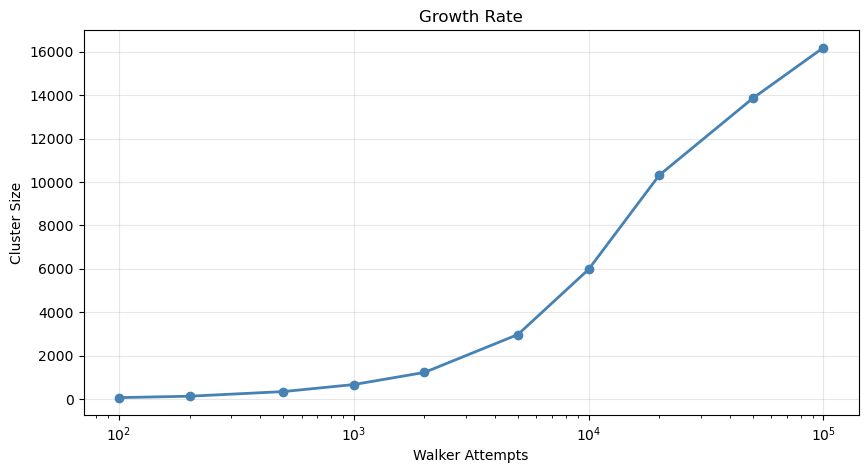

In [21]:
import random
import math
import matplotlib.pyplot as plt

def measure_growth_continuous(total_attempts, checkpoints, ratio=5.0):
    stuck = {(0, 0)}   
    sx = [0]           
    sy = [0]
    sizes = []
    
    for i in range(1, total_attempts + 1):
        max_extent = max(max(abs(px) for px, py in stuck), max(abs(py) for px, py in stuck))
        R_birth = max(max_extent + 5, 10)
        R_kill = R_birth * ratio
        
        angle = random.uniform(0, 2 * math.pi)
        x = int(R_birth * math.cos(angle))
        y = int(R_birth * math.sin(angle))
        
        for _ in range(5000):
            dx, dy = random.choice([(1,0), (-1,0), (0,1), (0,-1)])
            x += dx
            y += dy
            
            if x*x + y*y > R_kill * R_kill: 
                break
            
            stuck_flag = False
            for nx, ny in [(x+1,y), (x-1,y), (x,y+1), (x,y-1)]:
                if (nx, ny) in stuck:
                    stuck.add((x, y))
                    sx.append(x)
                    sy.append(y)
                    stuck_flag = True
                    break
            if stuck_flag:
                break
        
        if i in checkpoints:
            sizes.append(len(stuck) - 1)
    
    return sizes, sx, sy

checkpoints = [100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000]
total_attempts = 100000
print("Attempts: \t\t Size:")
sizes, sx, sy = measure_growth_continuous(total_attempts, checkpoints)

for i in range (len(checkpoints)):
    print(f"{checkpoints[i]} \t\t\t {sizes[i]}")

plt.figure(figsize=(10, 5))
plt.plot(checkpoints, sizes, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Walker Attempts')
plt.ylabel('Cluster Size')
plt.title('Growth Rate')
plt.xscale('log')
plt.grid(True, alpha=0.3)
plt.show()

For 100000 attempts the growth rate of the cluster increases as the number of walkers increase, keeping the steps constant throughout we get this graph. But to understand the nature of this graph we need to plot it and see its slope. We use `np.polyfit()` to get there.

Now what scaling should we use? 

We would like to go with log-log scaling. The raw numbers are hard to interpret. 100 attempts give 66 particles. 100,000 attempts give 16,186 particles. On a standard linear plot, the early data is crushed against the axis and the late data dominates.

A log-log plot spreads the data evenly across all five orders of magnitude. But there's a deeper reason. If the relationship is a power law : Size $\propto$ $Attempts^p$ ,then taking the logarithm of both sides gives:

$$\log(\text{Size}) = p \cdot \log(\text{Attempts}) + \text{constant}$$

This is the equation of a straight line. On a log-log plot, a power law becomes a straight line with slope p. We can read the exponent directly from the graph — no curve-fitting required.

If the relationship were exponential (Size $\propto e^\text{Attempts}$), a log-linear plot would straighten it. If it were logarithmic (Size $\propto log(\text{Attempts})$),
a linear-log plot would straighten it. Each transformation tests a different hypothesis.

So at the end we use polyfit to know exactly how the two orders are related.

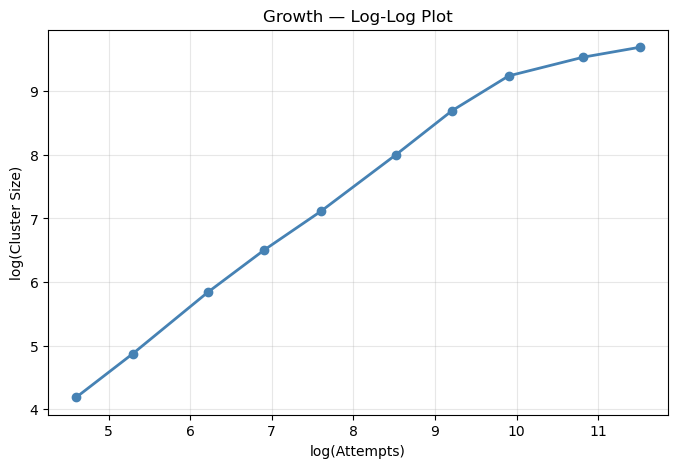

Slope = 0.839
Size is related by Attempts^0.839


In [25]:
import numpy as np

attempts = [100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000]
sizes = [66, 131, 343, 668, 1226, 2972, 5971, 10312, 13850, 16186]

log_attempts = np.log(attempts)
log_sizes = np.log(sizes)

plt.figure(figsize=(8, 5))
plt.plot(log_attempts, log_sizes, marker='o', color='steelblue', linewidth=2)
plt.xlabel('log(Attempts)')
plt.ylabel('log(Cluster Size)')
plt.title('Growth — Log-Log Plot')
plt.grid(True, alpha=0.3)
plt.show()


slope, intercept = np.polyfit(log_attempts, log_sizes, 1)
print(f"Slope = {slope:.3f}")
print(f"Size is related by Attempts^{slope:.3f}")

**RESULT**

The slope came out to be 0.839, The straightish line on the log-log plot confirms that the relationship is indeed a power law or close to one. The slope from `polyfit()` gives us the exponent: approximately **0.839**. The cluster grows as :

$$\text{Size} \propto \text{Attempts}^{0.839}$$

Growth is sublinear doubling the number of walkers does not double the cluster. The fractal's own branches shield the interior, and each new particle becomes harder to add than the last. The exponent 0.839 captures that slowdown in a single number.

## 7. Steps Per Walker vs Stick Rate
---
Every walker gets a fixed number of steps to find the cluster. If they run out they will be stranded, i.e., neither stuck nor killed. So we check that if we give every walker more and more steps does that increase their chacne of sticking to the cluster or there is a point where more steps doesn't help at all, if that exists we can find that. 


Steps 		 Stickrate
10 		 0.000
100 		 0.073
500 		 0.161
1000 		 0.310
5000 		 0.518
10000 		 0.780
50000 		 0.844
100000 		 0.787
500000 		 0.800


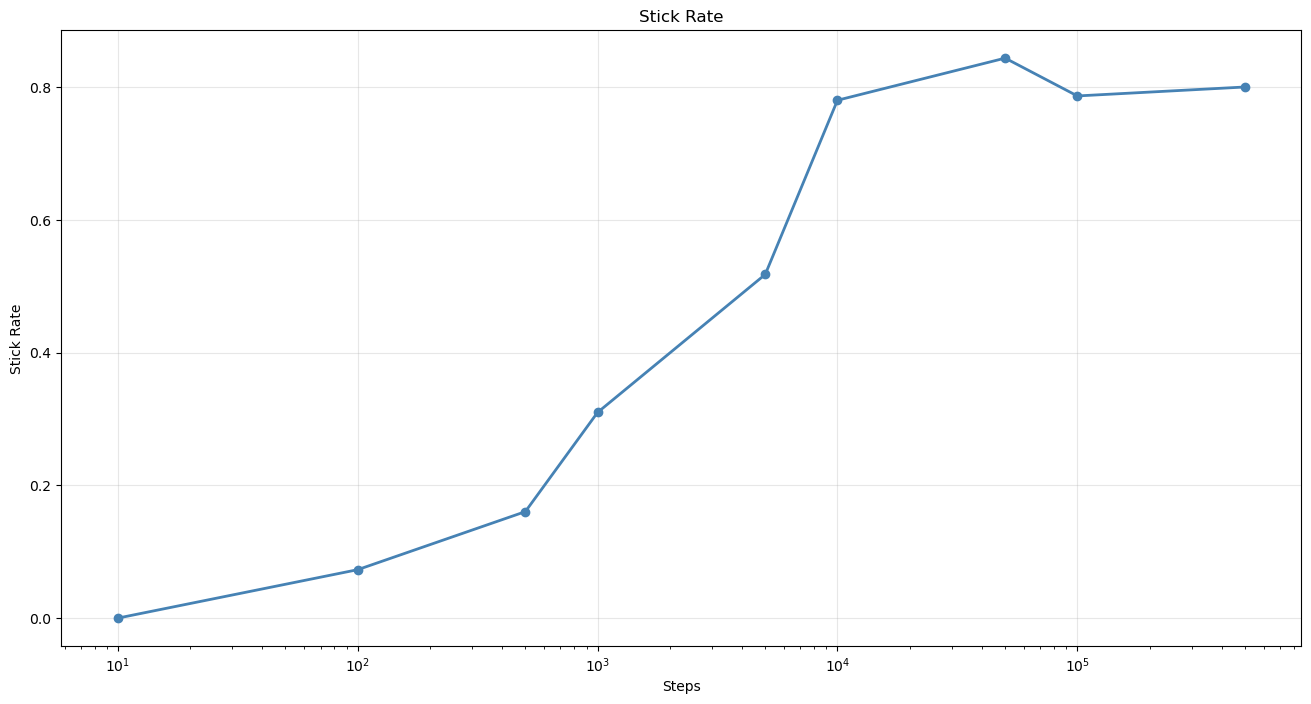

In [28]:
def measure_stickrate(steps,ratio=5.0):
    stuck={(0,0)}
    stick=0


    for i in range(2000):
        max_extent = max(max(abs(px) for px,py in stuck), max(abs(py) for px,py in stuck))
        R_birth=max(max_extent+5,10)
        R_kill= R_birth*ratio

        angle=random.uniform(0,2*math.pi)
        x=int(R_birth*math.cos(angle))
        y=int(R_birth*math.sin(angle))

        for i in range(steps):
            dx,dy=random.choice([(0,1),(0,-1),(1,0),(-1,0)])
            x+=dx
            y+=dy

            if x**2+y**2>R_kill**2:
                break

            stuck_flag=False
            for nx,ny in [(x+1,y),(x-1,y),(x,y+1),(x,y-1)]:
                if (nx,ny) in stuck:
                    stuck.add((x,y))
                    stick+=1
                    stuck_flag=True
                    break
            if stuck_flag:
                break
                
    return stick/2000
strate=[]
print("Steps \t\t Stickrate")
step_vals=[10,100,500,1000,5000, 10000,50000,100000,500000]
for steps in step_vals:
    strate_val= measure_stickrate(steps)
    strate.append(strate_val)
    print(f"{steps} \t\t {strate_val:.3f}")
    
plt.figure(figsize=(16, 8))

plt.plot(step_vals, strate, marker='o', color='steelblue', linewidth=2)
plt.xscale('log')
plt.xlabel('Steps')
plt.ylabel('Stick Rate')
plt.title('Stick Rate')
plt.grid(True, alpha=0.3)                   

**RESULT**

The stick rate rises from 0% (at 10 steps) to ~79% (at 10,000 steps), then plateaus. Between 10,000 and 500,000 steps, the rate barely moves from 79% to 80%.

This defines an optimal step limit: around 5,000-10,000 steps. Beyond that, computation time increases with negligible gain in sticking probability. The ~20% of walkers who haven't stuck by 10,000 steps are essentially lost they will drift forever, be killed, or exhaust themselves without ever touching the target.

At around 50000 steps it reaches a peak and then starts to move around that point upto 500,000. Thus adding 10x more steps doesnt even help the walker to reach the cluster. The value stays at ~80% from 10,000 to 500,000. Thus we can surely say that it plateaus around the area. To find the exact spot around which it mainly plateaus we write down the code. We check for the top ~95% of the data we had and if we reach there we stop and note that limit. The `enumerate()` gives us both index and value from the list.

Max stick rate: 0.844
95% threshold: 0.802
Optimal step limit: 50000 steps


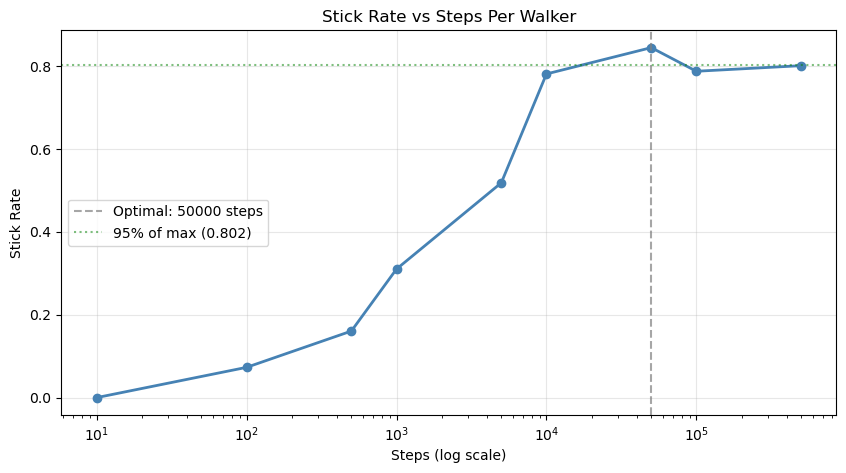

In [29]:
max_rate = max(strate)
threshold = 0.95 * max_rate

optimal_steps = None
for i, rate in enumerate(strate):
    if rate >= threshold:
        optimal_steps = step_vals[i]
        break

print(f"Max stick rate: {max_rate:.3f}")
print(f"95% threshold: {threshold:.3f}")
print(f"Optimal step limit: {optimal_steps} steps")

plt.figure(figsize=(10, 5))
plt.plot(step_vals, strate, marker='o', color='steelblue', linewidth=2)
plt.axvline(x=optimal_steps, linestyle='--', color='gray', alpha=0.7, label=f'Optimal: {optimal_steps} steps')
plt.axhline(y=threshold, linestyle=':', color='green', alpha=0.5, label=f'95% of max ({threshold:.3f})')
plt.xscale('log')
plt.xlabel('Steps (log scale)')
plt.ylabel('Stick Rate')
plt.title('Stick Rate vs Steps Per Walker')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

From here we can see that the green line 95% of the max is crossed at 50000 steps but we dont want to take that as the green line was crossed closer to 10000 steps. So any value between >10000 and <=50000 is perfect to get us the optimal size of the cluster. 

## 8. Assymetric Birth
---

Now we change things up, instead of random birth from any angle we select the birth points, to see does it affect the size and shape of the fractal or does the fractal depends on things like that. 
### a. Half Circle Birth:

We give a half circle around which the birth point gets generated everytime and instead of the entire circle we now have to work with the region from [0, $\pi$] And we plot a fractal to see how it forms.


Enter attempts: 10000


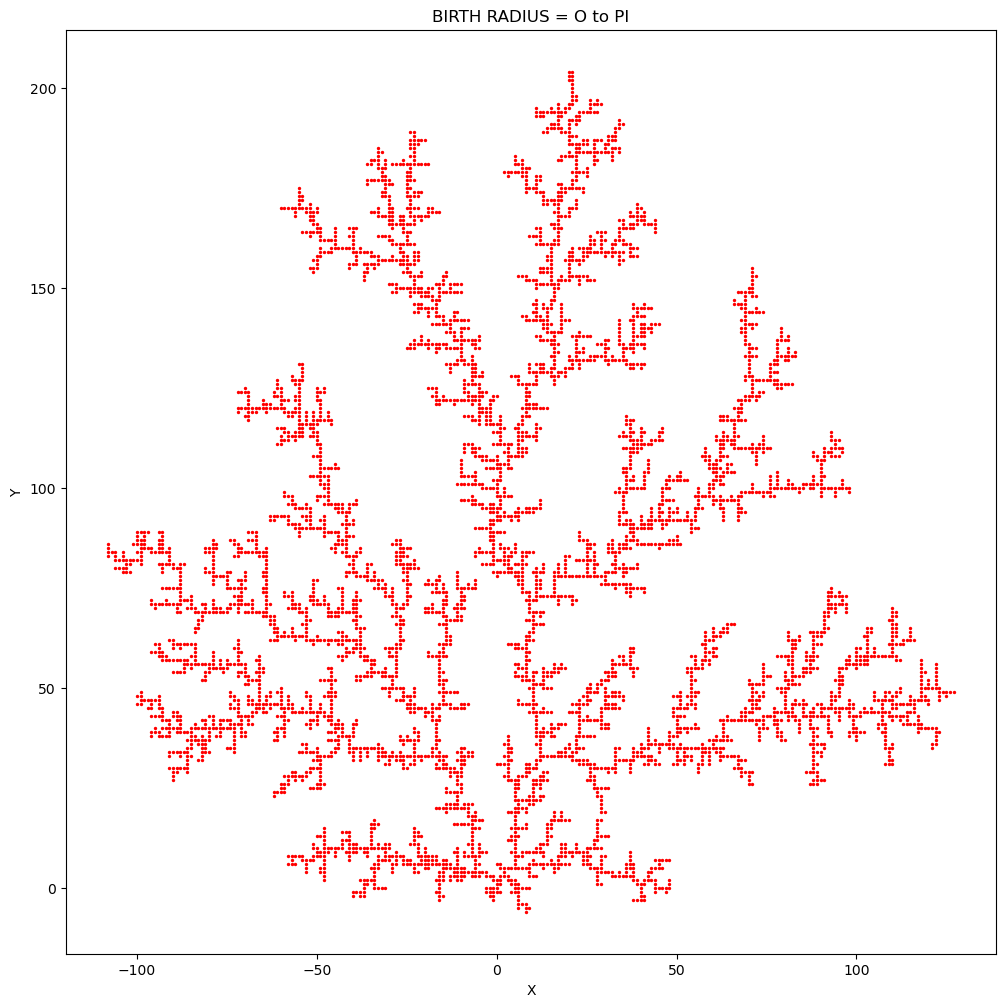

In [49]:
def run_dla(attempts, ratio=5.0):
    stuck = {(0, 0)}
    sx, sy = [0], [0]
    
    for i in range(attempts):
        max_extent = max(max(abs(px) for px, py in stuck), max(abs(py) for px, py in stuck))
        R_birth = max(max_extent + 5, 10)
        R_kill = R_birth * ratio
        
        
        angle = random.uniform(0, math.pi)
        x = int(R_birth * math.cos(angle))
        y = int(R_birth * math.sin(angle))
        
        for _ in range(10000):
            stuck_flag=False
            dx, dy = random.choice([(1,0), (-1,0), (0,1), (0,-1)])
            x += dx
            y += dy
            
            if x*x + y*y > R_kill * R_kill:
                break
            
            for nx, ny in [(x+1,y), (x-1,y), (x,y+1), (x,y-1)]:
                if (nx, ny) in stuck:
                    stuck.add((x, y))
                    sx.append(x)
                    sy.append(y)
                    stuck_flag = True
                    break
            if stuck_flag:
                break
    
    return sx, sy


attempts=int(input("Enter attempts:"))
sx,sy = run_dla(attempts)
plt.figure(figsize=(12,12))
plt.scatter(sx,sy,s=2, color='red')
plt.title("BIRTH RADIUS = O to PI")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

**RESULT**

With walkers born only in the upper half-plane (angles 0 to $\pi$), the fractal grows upward into the positive y region, toward the source. The lower half
remains sparse, starved of particles. The shape is no longer a symmetric snowflake but a directional growth, like a plant bending toward light. This is beacause a particle coming from the top half will easily encounter the origin and as more and more particles attach with it it grows to this.

This is DLA with a prevailing wind. The fractal's shape is not determined solely by the sticking rule. It is sculpted by where the particles come from.

### b. A Single Source:
---

Now if the particle comes from only one single source, we try to simulate that just instead of randomly selecting the angle lets just use $\frac{\pi} 2$ as the point of birth. And as the particles comes down to the origin they get stuck. Let us simulate that:

Enter attempts: 10000


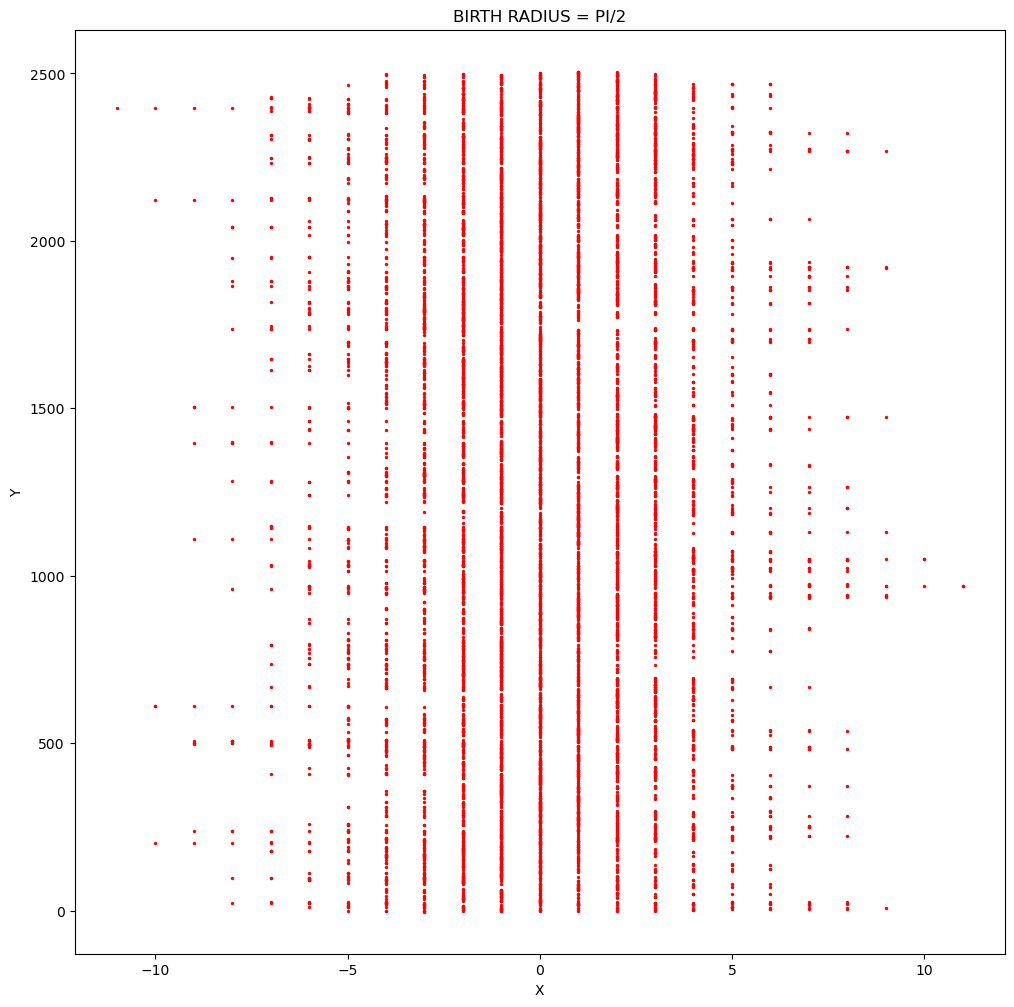

In [55]:
def run_dla(attempts, ratio=5.0):
    stuck = {(0, 0)}
    sx, sy = [0], [0]
    
    for i in range(attempts):
        max_extent = max(max(abs(px) for px, py in stuck), max(abs(py) for px, py in stuck))
        R_birth = max(max_extent + 5, 10)
        R_kill = R_birth * ratio
        
        
        angle = math.pi/2
        x = int(R_birth * math.cos(angle))
        y = int(R_birth * math.sin(angle))
        
        for _ in range(10000):
            stuck_flag=False
            dx, dy = random.choice([(1,0), (-1,0), (0,1), (0,-1)])
            x += dx
            y += dy
            
            if x*x + y*y > R_kill * R_kill:
                break
            
            for nx, ny in [(x+1,y), (x-1,y), (x,y+1), (x,y-1)]:
                if (nx, ny) in stuck:
                    stuck.add((x, y))
                    sx.append(x)
                    sy.append(y)
                    stuck_flag = True
                    break
            if stuck_flag:
                break
    
    return sx, sy


attempts=int(input("Enter attempts:"))
sx,sy = run_dla(attempts)
plt.figure(figsize=(12,12))
plt.scatter(sx,sy,s=2, color='red')
plt.title("BIRTH RADIUS = PI")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

**RESULT**

When all walkers are released from exactly directly above, the fractal collapses into a nearly straight vertical line. With no angular variation, every walker follows the same gravitational path. The result is not a branching fractal but a column-like sediment settling in still water, or a stalactite growing drop by drop.

The barcode style pattern reveals the slight left-right diffusion that remains. Even from a single point, random walks create fine structure microscopic variations on a singular direction.

### c. Top and Bottom:
What happens if we take 2 points one at the top and another at the bottom, and see the fractal grow? To answer this question instead of taking only one input we take 2 input (birth) positions randomly. For that we continuously choose either $\frac {\pi} {2}$ or $- \frac {\pi} {2}$.

Enter attempts: 10000


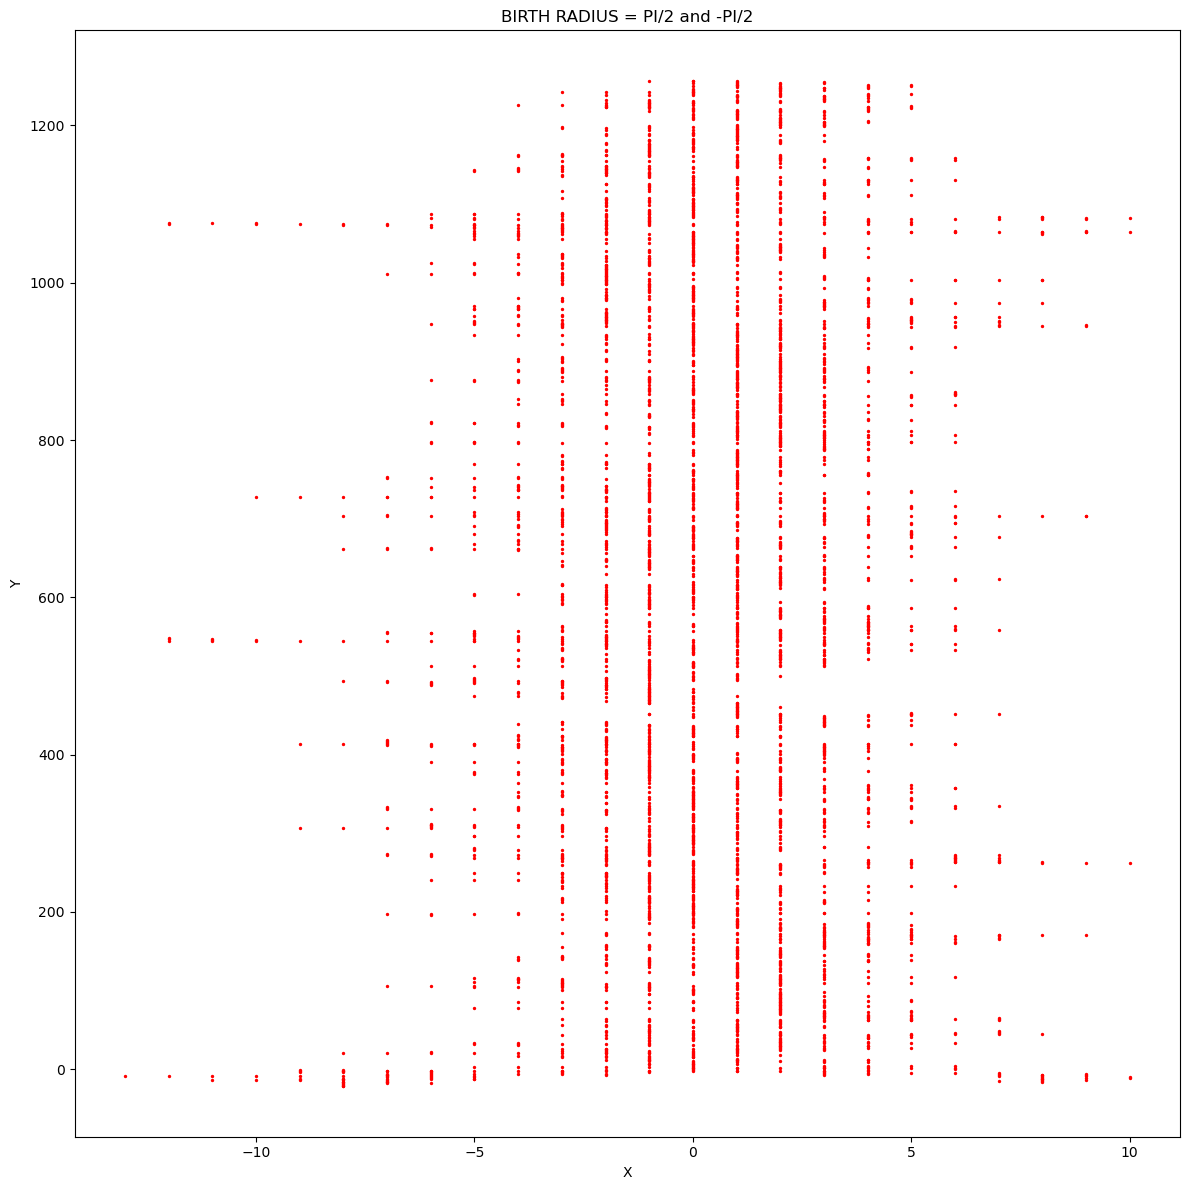

In [71]:
def run_dla(attempts, ratio=5.0):
    stuck = {(0, 0)}
    sx, sy = [0], [0]
    
    for i in range(attempts):
        max_extent = max(max(abs(px) for px, py in stuck), max(abs(py) for px, py in stuck))
        R_birth = max(max_extent + 5, 10)
        R_kill = R_birth * ratio
        
        angle = random.choice([math.pi/2, - math.pi/2])

        x = int(R_birth * math.cos(angle))
        y = int(R_birth * math.sin(angle))
        
        for _ in range(10000):
            stuck_flag=False
            dx, dy = random.choice([(1,0), (-1,0), (0,1), (0,-1)])
            x += dx
            y += dy
            
            if x*x + y*y > R_kill * R_kill:
                break
            
            for nx, ny in [(x+1,y), (x-1,y), (x,y+1), (x,y-1)]:
                if (nx, ny) in stuck:
                    stuck.add((x, y))
                    sx.append(x)
                    sy.append(y)
                    stuck_flag = True
                    break
            if stuck_flag:
                break
    
    return sx, sy


attempts=int(input("Enter attempts:"))
sx,sy = run_dla(attempts)
plt.figure(figsize=(12,12))
plt.scatter(sx,sy,s=2, color='red')
plt.title("BIRTH RADIUS = PI/2 and -PI/2")
plt.xlabel("X")
plt.ylabel("Y")
plt.tight_layout()
plt.show()

**RESULT**

The two arms are present but rarely equal. In most runs, one arm dominates reaching 100+ units while the other barely grows beyond 10. This is not a bug. It's the amplification of random chance.

The first few particles happen to stick slightly more on one side. That side grows faster, captures more walkers, and grows even faster. The losing side is shielded, walkers from both directions hit the dominant arm first.

Symmetry in the setup does not guarantee symmetry in the outcome. In DLA, small early advantages cascade into dramatic differences. This is how nature builds asymmetric structures from symmetric rules — why no two snowflakes are identical, why no two trees branch the same way, why every fractal is unique even when born from the same code.

### d. Left and Right Sources:
Now we just change the entry from top and bottom to left and right that is the zero degees and the -$\pi$ degrees. We plot it and we view the data:

Enter attempts: 10000


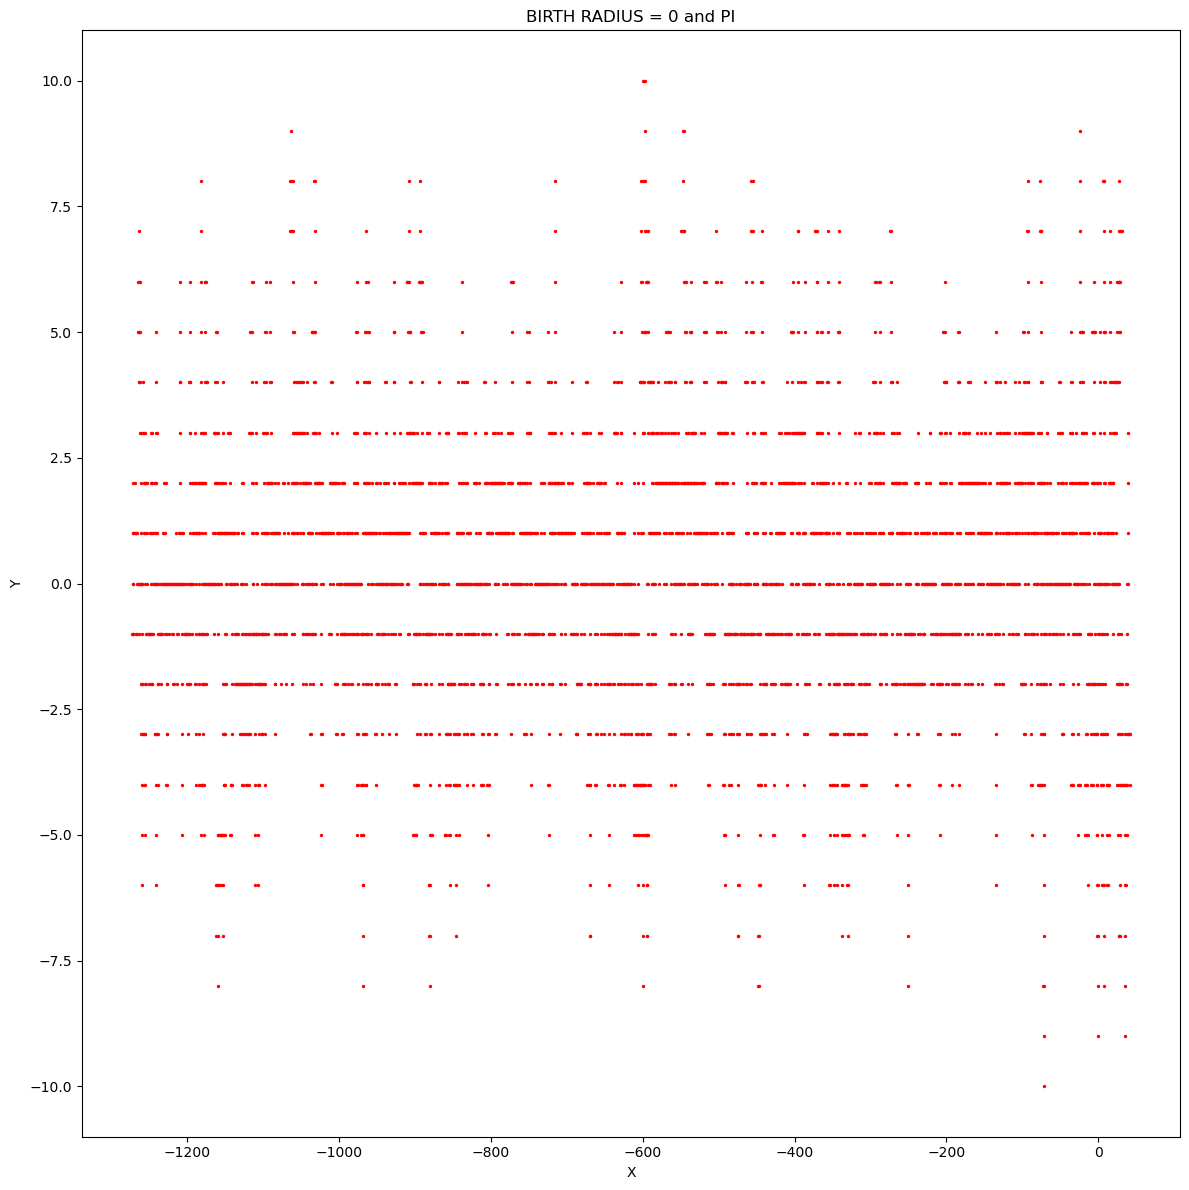

In [70]:
def run_dla(attempts, ratio=5.0):
    stuck = {(0, 0)}
    sx, sy = [0], [0]
    
    for i in range(attempts):
        max_extent = max(max(abs(px) for px, py in stuck), max(abs(py) for px, py in stuck))
        R_birth = max(max_extent + 5, 10)
        R_kill = R_birth * ratio
        
        angle = random.choice([0, math.pi])

        x = int(R_birth * math.cos(angle))
        y = int(R_birth * math.sin(angle))
        
        for _ in range(10000):
            stuck_flag=False
            dx, dy = random.choice([(1,0), (-1,0), (0,1), (0,-1)])
            x += dx
            y += dy
            
            if x*x + y*y > R_kill * R_kill:
                break
            
            for nx, ny in [(x+1,y), (x-1,y), (x,y+1), (x,y-1)]:
                if (nx, ny) in stuck:
                    stuck.add((x, y))
                    sx.append(x)
                    sy.append(y)
                    stuck_flag = True
                    break
            if stuck_flag:
                break
    
    return sx, sy


attempts=int(input("Enter attempts:"))
sx,sy = run_dla(attempts)
plt.figure(figsize=(12,12))
plt.scatter(sx,sy,s=2, color='red')
plt.title("BIRTH RADIUS = 0 and PI")
plt.xlabel("X")
plt.ylabel("Y")
plt.tight_layout()
plt.show()

**RESULT**

Same as we have seen previously one of the arms will dominate while the other will fall behind, just instead of top-down we have left-right approaching lines.

### The Fragility of Symmetry

Every directional run showed the same behavior: one arm dominates, the other
starves. Whether top-bottom or left-right, the fractal picks a preferred
direction early in its growth and amplifies that advantage relentlessly.

It is the physics of Diffusion-Limited Aggregation. The tips that happen to grow slightly faster capture more walkers and grow even faster. The losing tips are shielded and starve. Small random fluctuations at the start become permanent asymmetries in the final shape.

DLA does not balance. It commits. This is why snowflakes have sixfold symmetry
(governed by crystal structure, not random growth) while electroplated metal
deposits are wildly asymmetric. Remove the guiding lattice, and randomness
chooses winners and losers without hesitation.

## 9. Fractal Dimension
---

We've watched the fractal grow. We've measured its size. But there is a deeper question: how *efficiently* does it fill space?

A solid circle fills the plane completely. Its dimension is 2. A straight line barely fills anything. Its dimension is 1. Our fractal — branching, gapped,
spidery — lives somewhere in between.

The **fractal dimension** is a number that captures this in-betweenness. It answers: if we draw a circle of radius r around the seed, how many
particles $N(r)$ lie inside? For a solid circle, $ N \propto r^2 $ for a line, $ N \propto r^1 $. For a fractal, $ N \propto r^D$ , where D is not 1 or 2 but in between.

This number is the fractal dimension. It is the signature of Diffusion-Limited Aggregation. It has been measured in electroplated metal, in coral branches, in lightning scars. Wherever DLA occurs in nature, the fractal dimension tends to be the same.

We can measure it ourselves. Count particles inside circles of increasing radius. Plot log(N) against log(r). The slope is D.

For that we create a fractal and plot it out.

Enter number of attempts 15000
Enter number of steps 10000


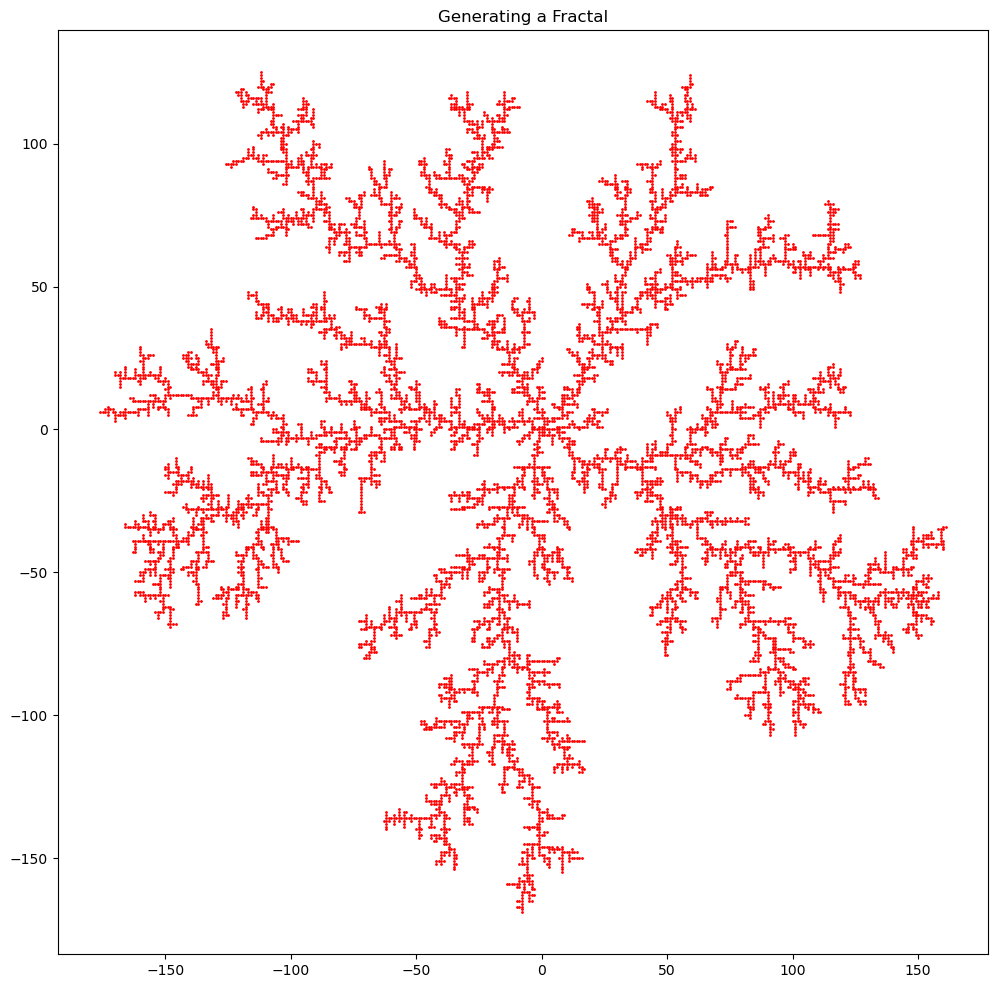

In [78]:
def run_dla(attempts, steps, ratio=5.0):
    stuck = {(0, 0)}
    sx, sy = [0], [0]
    
    for i in range(attempts):
        max_extent = max(max(abs(px) for px, py in stuck), max(abs(py) for px, py in stuck))
        R_birth = max(max_extent + 5, 10)
        R_kill = R_birth * ratio
        
        angle = random.uniform(0,2*math.pi)

        x = int(R_birth * math.cos(angle))
        y = int(R_birth * math.sin(angle))
        
        for _ in range(steps):
            stuck_flag=False
            dx, dy = random.choice([(1,0), (-1,0), (0,1), (0,-1)])
            x += dx
            y += dy
            
            if x*x + y*y > R_kill * R_kill:
                break
            
            for nx, ny in [(x+1,y), (x-1,y), (x,y+1), (x,y-1)]:
                if (nx, ny) in stuck:
                    stuck.add((x, y))
                    sx.append(x)
                    sy.append(y)
                    stuck_flag = True
                    break
            if stuck_flag:
                break
    
    return sx, sy

attempts=int(input("Enter number of attempts"))
steps=int(input("Enter number of steps"))

sx,sy=run_dla(attempts,steps)

plt.figure(figsize=(12,12))
plt.scatter(sx,sy,s=1, color='red')
plt.title("Generating a Fractal")
plt.show()

Fractal Dimension=1.591


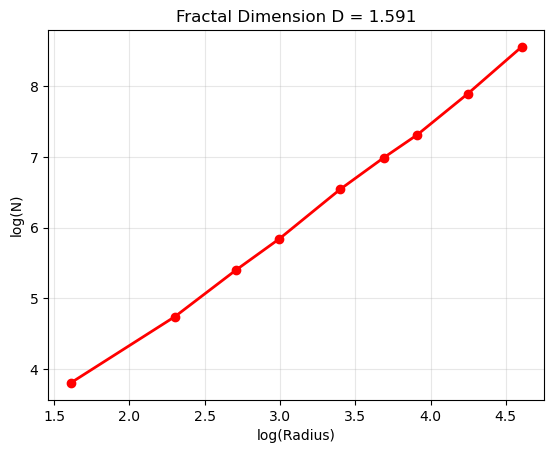

In [80]:
radii = [5,10,15,20,30,40,50,70,100]
log_r=[]
log_n=[]

for r in radii:
    count=0
    for x,y in zip(sx,sy):
        if x*x+y*y<=r*r:
            count+=1
    log_r.append(math.log(r))
    log_n.append(math.log(count))
slope,intercept=np.polyfit(log_r,log_n,1)

print(f"Fractal Dimension={slope:.3f}")

plt.plot(log_r, log_n, marker='o', color='red', linewidth=2)
plt.xlabel('log(Radius)')
plt.ylabel('log(N)')
plt.title(f'Fractal Dimension D = {slope:.3f}')
plt.grid(True, alpha=0.3)
plt.show()

**RESULT**

Our measured fractal dimension is **1.591**. The theoretical value is approximately **1.71**.

The difference is expected. True DLA scaling emerges only at very large
cluster sizes. Hundreds of thousands or millions of particles. At 10,000
particles, our cluster is still young. Gaps are wider than they would be
at scale. The fractal dimension is approaching the theoretical value but
has not fully converged.

That we got within ~0.12 of the accepted value without supercomputing resources, without parallel code, on a laptop, confirms that our simulation captures the essential physics of Diffusion-Limited Aggregation.

## 10. The Final Fractal 
---

We began with one of our drunk walker. One bar. One random step.

Now we release fifty thousand walkers.

This is the culmination of every lesson learned: dynamic birth radius, optimized neighbor checks, squared distances, the sweet-spot kill ratio. All the failures and fixes, the cages broken, the killers pushed back all leading here.

What emerges is not a blob. Not a crystal. Not a tree. But something that resembles all of them and none of them. A fractal. Branches upon branches. Gaps that remain unfilled because tips grew faster than interiors. A shape built entirely by random motion and a single rule: *touch it, and you
belong to it forever.*

No two runs will produce the same fractal. Randomness guarantees uniqueness.
But the fractal dimension — ~1.71 — is universal. The branching pattern is
universal. The rich-get-richer tip growth is universal.

The drunk men have built their own cathedral before the bar opens the next day.

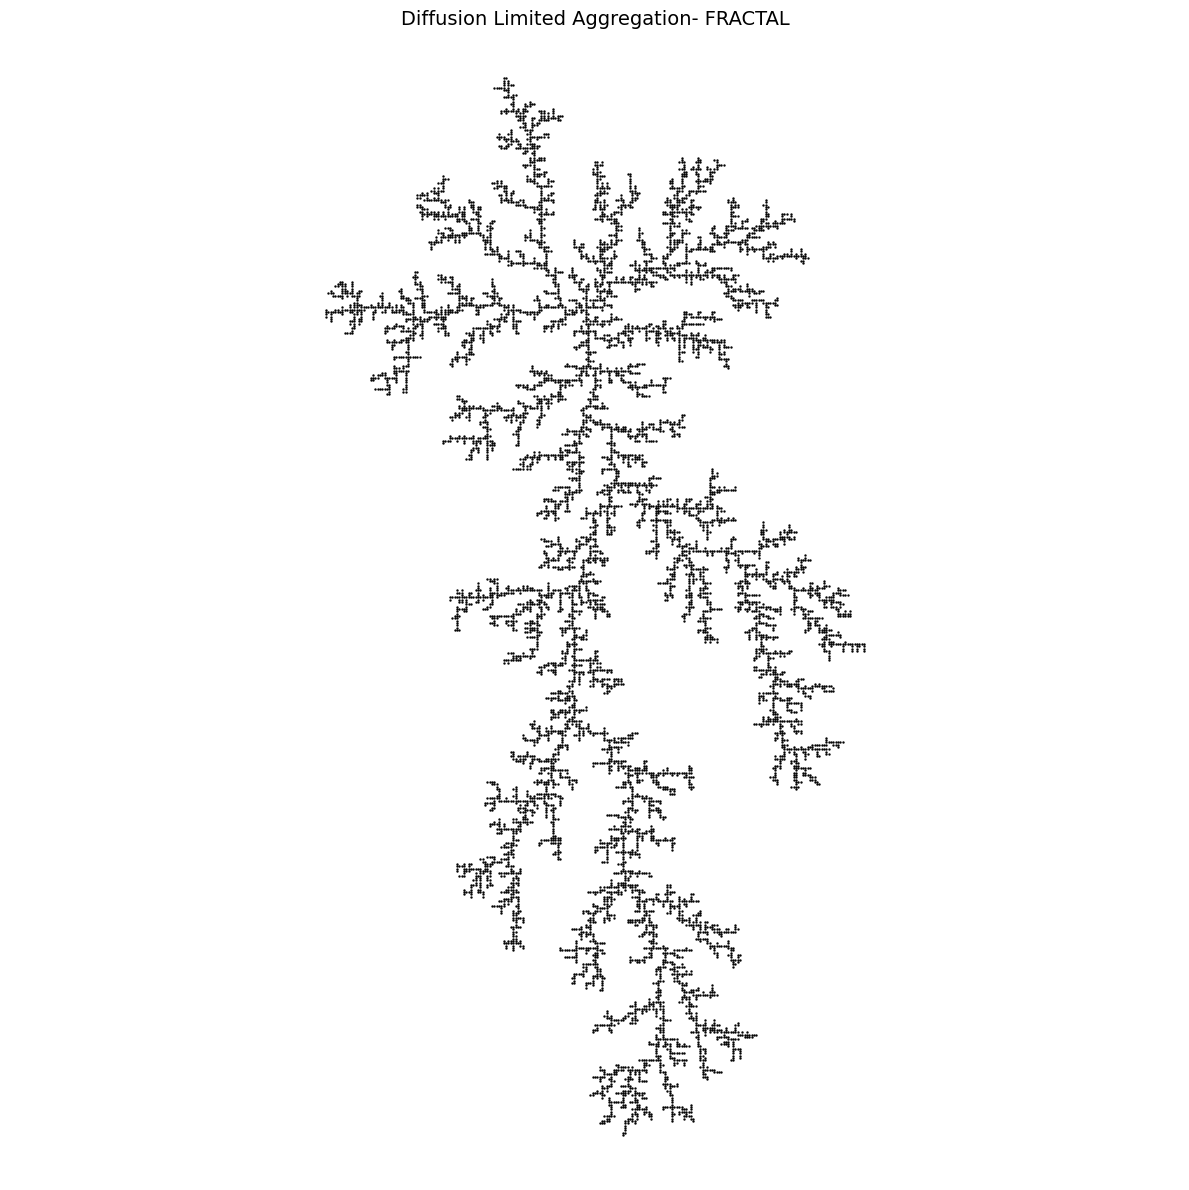

In [83]:
def run_dla(ratio=5.0):
    stuck = {(0, 0)}
    sx, sy = [0], [0]
    
    for i in range(50000):
        max_extent = max(max(abs(px) for px, py in stuck), max(abs(py) for px, py in stuck))
        R_birth = max(max_extent + 5, 10)
        R_kill = R_birth * ratio
        
        angle = random.uniform(0, 2*math.pi)

        x = int(R_birth * math.cos(angle))
        y = int(R_birth * math.sin(angle))
        
        for _ in range(10000):
            stuck_flag=False
            dx, dy = random.choice([(1,0), (-1,0), (0,1), (0,-1)])
            x += dx
            y += dy
            
            if x*x + y*y > R_kill * R_kill:
                break
            
            for nx, ny in [(x+1,y), (x-1,y), (x,y+1), (x,y-1)]:
                if (nx, ny) in stuck:
                    stuck.add((x, y))
                    sx.append(x)
                    sy.append(y)
                    stuck_flag = True
                    break
            if stuck_flag:
                break
    
    return sx, sy

sx,sy = run_dla()

plt.figure(figsize=(12, 12))
plt.scatter(sx, sy, s=0.5, color='black')
plt.axis('equal')
plt.axis('off')
plt.title('Diffusion Limited Aggregation- FRACTAL', fontsize=14)
plt.tight_layout()
plt.show()


This pattern came out to be more beautiful than I could expect. I really enjoyed working on this and visualizing all these different fractals that can only generate once and cannot be reproduced.

## Conclusion 
---

We started with a drunk man. One walker, one bar, one random step. We end with fifty thousand drunk men frozen in place, a fractal built from nothing but random motion and a rule.

| Experiment | What It Taught Us |
|------------|-------------------|
| Single walker | Most die. Some stick. Chance decides. |
| Dynamic birth radius | The cage breaks. The fractal breathes. |
| Kill ratio sweep | Too close starves. Too far bloats. The killer is the sculptor. |
| Growth rate | $ Size \propto Attempts^{0.839}$, sublinear, bending toward theory |
| Stick rate plateau | 10,000 steps is enough. Beyond that, waste. |
| Asymmetric birth | The fractal reaches toward its source. Symmetry is fragile. |
| Two sources | One arm dominates. Early luck becomes permanent fate. |
| Fractal dimension | D = 1.59, approaching the universal ~1.71 |

Diffusion-Limited Aggregation is not complicated. Particles wander randomly. They stick on contact. That's all.

From this poverty of rules comes a richness of structure: branches, gaps, fractal dimensions, directional growth, winner-take-all asymmetry. The universe builds complexity the same way — not by designing it, but by letting random motion run long enough that patterns emerge.

The drunk man had a wonderful journey. He started in 1D, stumbling left and right, teaching us diffusion. He moved to 2D, wandered through mazes, burned through forests. Now he has frozen in place — part of something larger than himself.

The Monte Carlo method brought us here. Random numbers with Repeated trials giving emergence to order. From $\pi$ to percolation to fractals, we never solved an equation. Simulation lead us to here. 

### Limitations

Our simulation, for all its beauty, is a simplified shadow of nature. But there are limitations:

- **Two dimensions only.** Real DLA happens in 3D — electroplated metal,
  soot particles, mineral veins. Our 2D fractal hints at the structure
  but cannot capture the full complexity of volumetric growth.

- **Perfect sticking.** Every contact is permanent. In reality, particles
  can detach, diffuse along the surface, or rearrange. Temperature,
  solvent, and surface energy all affect attachment, none of which
  exist in our model.

- **No external fields.** Gravity, electric fields, fluid flow are all absent.
  Our walkers are driven only by randomness. Real deposition is shaped by
  forces we did not simulate.

- **Cluster size.** 50,000 particles is large for my device but microscopic
  for nature. True DLA scaling emerges at millions of particles. Our
  fractal dimension of 1.59 is approaching the universal 1.71, but the
  asymptotic limit remains out of reach.

- **Discrete grid.** Our walkers move on integer coordinates with fixed
  step size. In reality, Brownian motion is continuous. The grid leaves
  its fingerprint on the fractal's fine structure.

### Applications in the Real World:

The same rules random motion, permanent attachment govern phenomena across vastly different scales:

| Phenomenon | What Diffuses | What Aggregates |
|------------|---------------|-----------------|
| Electroplating | Metal ions in solution | Metal deposit on electrode |
| Lightning | Electrons in air | Ionized plasma channel |
| Snowflakes | Water vapor molecules | Ice crystal |
| Coral growth | Calcium carbonate | Coral skeleton |
| Soot formation | Carbon particles | Soot aggregates in smoke |
| Blood vessels | Endothelial cells | Capillary networks |
| River networks | Water | Eroded channels |
| Dielectric breakdown | Electric charge | Damage tracks in insulators |

In every case, the microscopic rule is the same: particles move randomly
until they touch something, then they stay. The macroscopic result —
branching, fractal, asymmetric that emerges without being programmed.

Our simulation did not model electrochemistry or fluid dynamics or
atmospheric physics. It modeled only the random walk and the sticking rule.
And yet the shape it produced echoes all of these phenomena.

### Why I should RETURN here:

The fractal dimension hasn't fully converged to 1.71. The growth curve hasn't fully bent to its asymptotic slope. These are not failures. They are the boundary between what a laptop can simulate and what a cluster can discover. They are invitations to return — with better code, with parallelism, with GPUs, with time.

The drunk man is part of the fractal now. But he'll walk again.

---